In [1]:
##import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'Y dataset')

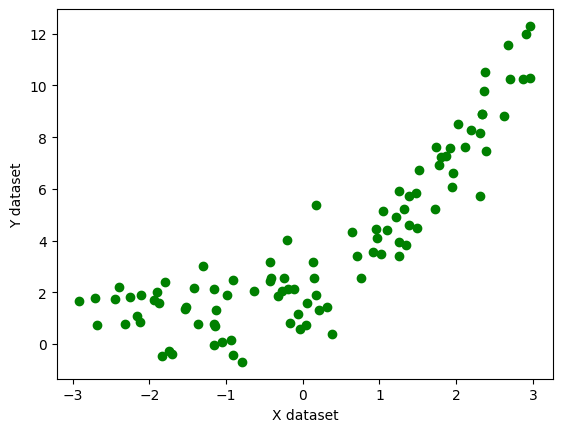

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5*X + 2 + np.random.randn(100, 1)

# quadratic equation used- y=0.5x^2+1.5x+2+outliers
plt.scatter(X, y, color='g')
plt.xlabel('X dataset')
plt.ylabel('Y dataset')

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [4]:
# Lets implement Simple Linear Regression
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()

In [5]:
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
from sklearn.metrics import r2_score
score = r2_score(y_test, regression_1.predict(X_test))
print(score)

0.754853400955754


Text(0, 0.5, 'Y')

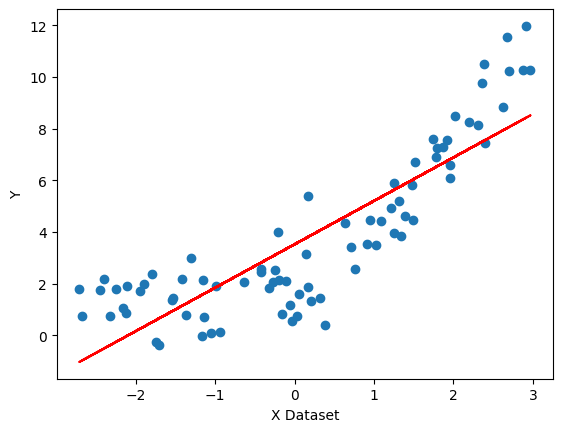

In [7]:
# Lets visualize this model
plt.plot(X_train, regression_1.predict(X_train), color='r')
plt.scatter(X_train, y_train)
plt.xlabel("X Dataset")
plt.ylabel("Y")

In [8]:
# LEts apply polynomial transformation
from sklearn.preprocessing import PolynomialFeatures

In [9]:
poly = PolynomialFeatures(degree=2, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [10]:
X_train_poly

array([[ 1.00000000e+00,  7.12912937e-01,  5.08244856e-01],
       [ 1.00000000e+00, -4.15926102e-01,  1.72994522e-01],
       [ 1.00000000e+00, -1.12302955e-01,  1.26119536e-02],
       [ 1.00000000e+00, -5.77342355e-02,  3.33324195e-03],
       [ 1.00000000e+00,  1.73983550e+00,  3.02702757e+00],
       [ 1.00000000e+00, -9.91498196e-01,  9.83068674e-01],
       [ 1.00000000e+00,  2.19341659e+00,  4.81107634e+00],
       [ 1.00000000e+00, -3.24456621e-01,  1.05272099e-01],
       [ 1.00000000e+00, -1.73805413e+00,  3.02083215e+00],
       [ 1.00000000e+00, -1.41218194e+00,  1.99425784e+00],
       [ 1.00000000e+00,  3.83518346e-01,  1.47086322e-01],
       [ 1.00000000e+00,  1.02319051e+00,  1.04691882e+00],
       [ 1.00000000e+00, -1.89623513e+00,  3.59570768e+00],
       [ 1.00000000e+00, -2.67483447e-01,  7.15473942e-02],
       [ 1.00000000e+00,  6.37781934e-01,  4.06765795e-01],
       [ 1.00000000e+00, -2.70639470e+00,  7.32457226e+00],
       [ 1.00000000e+00,  1.31438335e+00

In [11]:
X_test_poly

array([[ 1.        ,  2.96341484,  8.78182751],
       [ 1.        ,  1.38991899,  1.9318748 ],
       [ 1.        ,  1.25472962,  1.57434643],
       [ 1.        ,  2.3086596 ,  5.32990913],
       [ 1.        , -1.87910563,  3.53103798],
       [ 1.        , -1.83064782,  3.35127145],
       [ 1.        ,  2.33384653,  5.44683963],
       [ 1.        ,  1.04140019,  1.08451436],
       [ 1.        , -0.7940166 ,  0.63046235],
       [ 1.        ,  2.33143827,  5.43560442],
       [ 1.        , -0.90966877,  0.82749727],
       [ 1.        , -1.1610863 ,  1.34812139],
       [ 1.        ,  1.72121441,  2.96257904],
       [ 1.        , -0.43312568,  0.18759785],
       [ 1.        ,  0.15227116,  0.02318651],
       [ 1.        , -2.91134433,  8.47592583],
       [ 1.        ,  0.96630129,  0.93373819],
       [ 1.        ,  2.11932671,  4.4915457 ],
       [ 1.        , -1.13297925,  1.28364197],
       [ 1.        , -0.90930763,  0.82684036]])

In [12]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.8833108121299053


In [13]:
print(regression.coef_)

[[0.         1.52353375 0.544895  ]]


In [14]:
print(regression.intercept_)

[2.12169653]


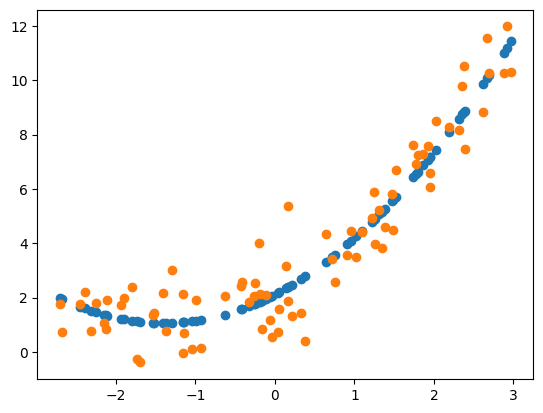

In [15]:
plt.scatter(X_train, regression.predict(X_train_poly))
plt.scatter(X_train, y_train)

In [16]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [17]:
X_train_poly

array([[ 1.00000000e+00,  7.12912937e-01,  5.08244856e-01,
         3.62334333e-01],
       [ 1.00000000e+00, -4.15926102e-01,  1.72994522e-01,
        -7.19529372e-02],
       [ 1.00000000e+00, -1.12302955e-01,  1.26119536e-02,
        -1.41635966e-03],
       [ 1.00000000e+00, -5.77342355e-02,  3.33324195e-03,
        -1.92442176e-04],
       [ 1.00000000e+00,  1.73983550e+00,  3.02702757e+00,
         5.26653003e+00],
       [ 1.00000000e+00, -9.91498196e-01,  9.83068674e-01,
        -9.74710817e-01],
       [ 1.00000000e+00,  2.19341659e+00,  4.81107634e+00,
         1.05526947e+01],
       [ 1.00000000e+00, -3.24456621e-01,  1.05272099e-01,
        -3.41562296e-02],
       [ 1.00000000e+00, -1.73805413e+00,  3.02083215e+00,
        -5.25036979e+00],
       [ 1.00000000e+00, -1.41218194e+00,  1.99425784e+00,
        -2.81625491e+00],
       [ 1.00000000e+00,  3.83518346e-01,  1.47086322e-01,
         5.64103029e-02],
       [ 1.00000000e+00,  1.02319051e+00,  1.04691882e+00,
      

In [18]:

from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, y_train)
y_pred = regression.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score)

0.8853500858419638


In [19]:
# 3 Prediction of new data set
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
X_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

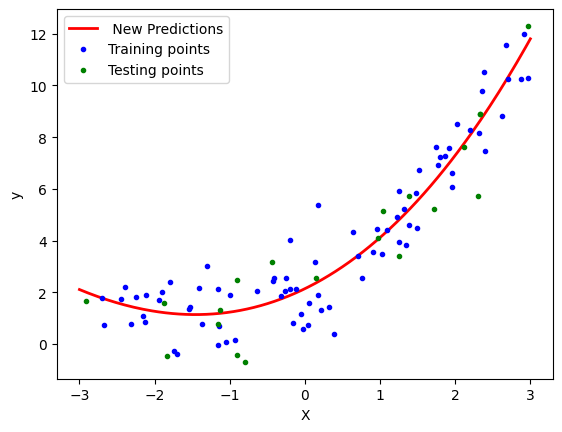

In [20]:
y_new = regression.predict(X_new_poly)
plt.plot(X_new, y_new, "r-", linewidth=2, label=" New Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Pipeline Concepts 

In [23]:
from sklearn.pipeline import Pipeline

In [24]:
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=True)
    lin_reg = LinearRegression()
    poly_regression = Pipeline([
        ("poly_features", poly_features),
        ("lin_reg", lin_reg)
    ])
    # ploynomial and fit of linear reression
    poly_regression.fit(X_train, y_train)
    y_pred_new = poly_regression.predict(X_new)
    # plotting prediction line
    plt.plot(X_new, y_pred_new, 'r', label="Degree " +
             str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4, 4, 0, 10])
    plt.show()

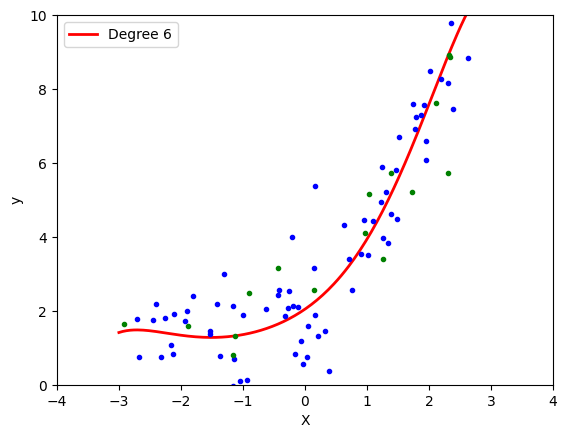

In [25]:
poly_regression(6)

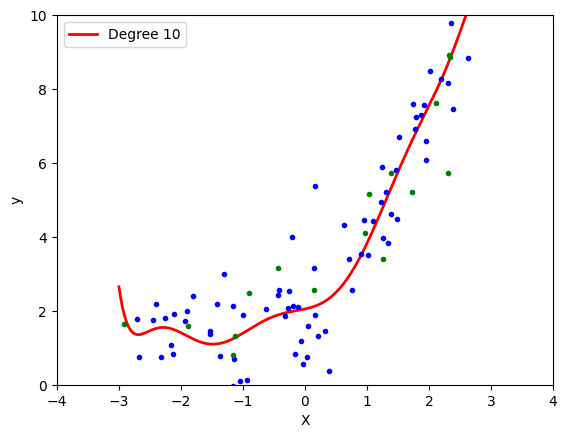

In [26]:
poly_regression(10)

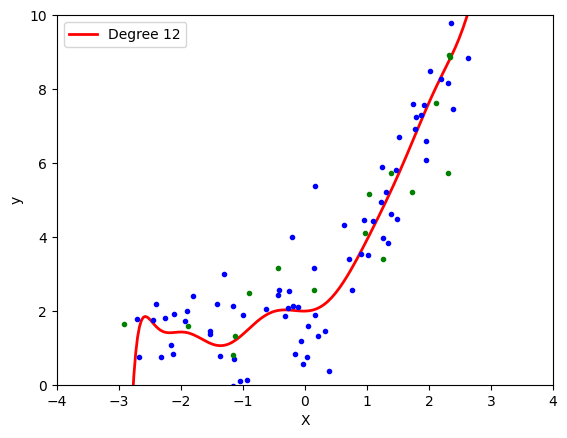

In [27]:
poly_regression(12)